# Tutorial 1: Integrating adjacent DLPFC slices
This tutorial demonstrates STAligner's ablility to integrate multiple adjacent slices. The slices are sampled from human dorsolateral prefrontal cortex (DLPFC) and the processed data can be downloaded from https://drive.google.com/drive/folders/1pHJy2cB9BKqc3ny9IpvVhiw_8ukJMzPW?usp=share_link.

## Preparation

In [4]:
import os
import anndata
import scanpy as sc
import random
import torch
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import sys
import os

from pathlib import Path
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import silhouette_score as s_score

stClinic_root = r'E:\yan0\multi-sample-disentangle\baseline\stClinic-main\stClinic-main'
if os.path.exists(stClinic_root) and stClinic_root not in sys.path:
    sys.path.insert(0, stClinic_root)

import stClinic as stClinic

warnings.filterwarnings("ignore")

E:\yan0\multi-sample-disentangle\baseline\stClinic-main\stClinic-main\stClinic\Module.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange


In [6]:
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(used_device)

cuda:0


In [7]:
# Set seed
seed    = 666
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

## Load Data

In [29]:
# Load data
# section_ids = ['151673','151674','151675','151676']
section_ids = ['G2','H1']
print(section_ids)
Batch_list  = []
adj_list    = []

for idx, section_id in enumerate(section_ids):
    # file_fold = 'E:/yan0/Papers/data/paste/data/'  #please replace 'file_fold' with the download path
    # adata = sc.read_h5ad(file_fold + section_id + '_preprocessed.h5')
    adata = sc.read_h5ad('E:\yan0\multi-sample-disentangle\multi-sample-data\STANDS/' + section_id + '.h5ad')
    adata.var_names_make_unique(join="++")

    adata.obs['Ground Truth'] = adata.obs['cell_type'].astype('category')
    adata.obs_names = [x+'_'+section_id for x in adata.obs_names]

    # Construct intra-edges
    stClinic.Cal_Spatial_Net(adata, rad_cutoff=500)

    # Normalization
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata = adata[:, adata.var['highly_variable']]

    sc.tl.pca(adata, n_comps=10, random_state=seed)

    adj_list.append(adata.uns['adj'])
    Batch_list.append(adata)

# Concat scanpy objects
adata_concat = anndata.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"]   = adata_concat.obs["slice_name"].astype('category')
print('\nShape of concatenated AnnData object: ', adata_concat.shape)

# Construct unified graph
# mnn_dict = create_dictionary_mnn(adata_concat, use_rep='X_pca', batch_name='batch_name', k=1) # k=0
adj_concat = stClinic.inter_linked_graph(adj_list, section_ids, mnn_dict=None)
adata_concat.uns['adj']      = adj_concat
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

['G2', 'H1']
------Calculating intra-spatial graph...
The graph contains 3416 edges, 467 cells.
7.3148 neighbors per spot on average.
------Calculating intra-spatial graph...
The graph contains 4570 edges, 613 cells.
7.4551 neighbors per spot on average.

Shape of concatenated AnnData object:  (1080, 3000)


## Running STAligner

In [30]:
# Run stClinic for unsupervised integration
centroids_num = 7
print(f'Estimated centroids number: {centroids_num}')
adata_concat  = stClinic.train_stClinic_model(adata_concat, n_centroids=centroids_num, lr=0.0005, device=used_device)

# Clustering
stClinic.mclust_R(adata_concat, num_cluster=len(np.unique(adata_concat.obs[adata_concat.obs['Ground Truth']!='unknown']['Ground Truth'])), used_obsm='stClinic')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

Batch_list1   = []
for section_id in section_ids:
	Batch_list1.append(adata_concat[adata_concat.obs['batch_name'] == section_id])

Estimated centroids number: 7
Pretrain with unregularized stClinic (without GMM regularizer)...


Epochs:   0%|          | 0/300 [00:00<?, ?it/s]

Initialize Gaussian Mixture Model...
Selected initial type: GMM
Train with regularized stClinic (with GMM regularizer)...


Epochs:   0%|          | 0/400 [00:00<?, ?it/s]

Prune edges...
Prune edges...
fitting ...
  |======================================================================| 100%


In [31]:
adata_concat

View of AnnData object with n_obs × n_vars = 1080 × 3000
    obs: 'cell_type', 'batch', 'disease', 'Ground Truth', 'slice_name', 'batch_name', 'GMM_cluster', 'mclust'
    uns: 'adj', 'edgeList'
    obsm: 'spatial', 'X_pca', 'stClinic'

## Clustering

In [24]:
# Clustering
stClinic.mclust_R(adata_concat, num_cluster=len(np.unique(adata_concat.obs[adata_concat.obs['Ground Truth']!='unknown']['Ground Truth'])), used_obsm='stClinic')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

Batch_list1   = []
for section_id in section_ids:
	Batch_list1.append(adata_concat[adata_concat.obs['batch_name'] == section_id])
    

fitting ...
  |======================================================================| 100%


## Visualization

In [ ]:
# UMAP reduction
sc.pp.neighbors(adata_concat, use_rep='stClinic', random_state=seed)
sc.tl.umap(adata_concat, random_state=seed)

Text(0.5, 1.0, 'ARI=0.41')

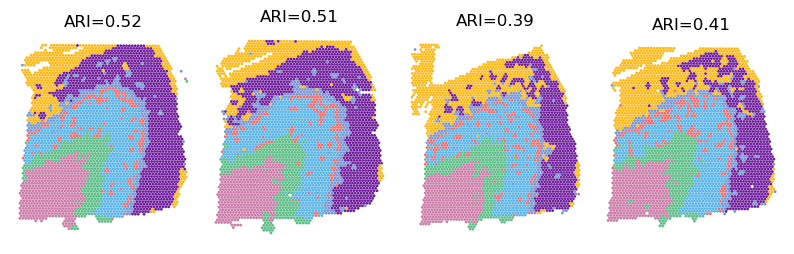

In [27]:

spot_size  = 6
title_size = 12
ARI_list   = []
for bb in range(4):
	ARI_list.append(round(ari_score(Batch_list1[bb].obs['Ground Truth'], Batch_list1[bb].obs['mclust']), 2))

colors  = ["#6D1A9B", "#CB79A6", "#7494D2", "#59BD85", "#56B3E8", "#FDB815", "#F46867"]
fig, ax = plt.subplots(1, 4, figsize=(10, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})

_sc_0 = sc.pl.spatial(Batch_list1[0], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None, 
					  legend_fontsize=12, show=False, ax=ax[0], frameon=False, palette=colors)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=12)
_sc_1 = sc.pl.spatial(Batch_list1[1], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[1], frameon=False, palette=colors)
_sc_1[0].set_title("ARI=" + str(ARI_list[1]), size=12)
_sc_2 = sc.pl.spatial(Batch_list1[2], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[2], frameon=False, palette=colors)
_sc_2[0].set_title("ARI=" + str(ARI_list[2]), size=12)
_sc_3 = sc.pl.spatial(Batch_list1[3], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[3], frameon=False, palette=colors)
_sc_3[0].set_title("ARI=" + str(ARI_list[3]), size=12)

Text(0.5, 1.0, 'ARI=0.4')

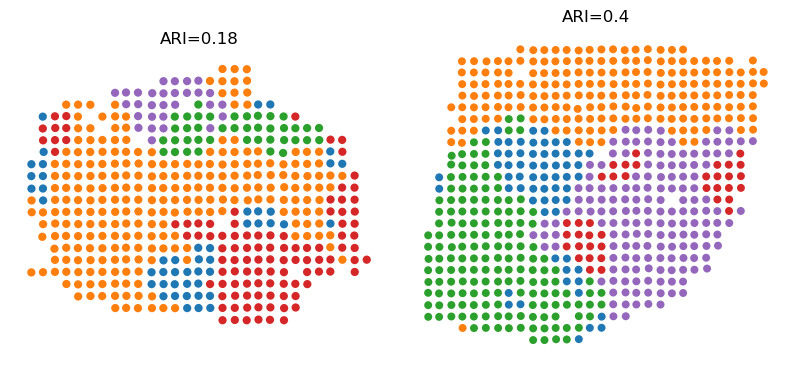

In [33]:
Batch_list = []
for section_id in section_ids:
    Batch_list.append(adata_concat[adata_concat.obs['batch_name'] == section_id])

import matplotlib.pyplot as plt
spot_size = 200
title_size = 12
ARI_list = []
for bb in range(2):
    ARI_list.append(round(ari_score(Batch_list[bb].obs['Ground Truth'], Batch_list[bb].obs['mclust']), 2))

fig, ax = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
_sc_0 = sc.pl.spatial(Batch_list[0], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[0], frameon=False,
                      spot_size=spot_size)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=title_size)
_sc_1 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[1], frameon=False,
                      spot_size=spot_size)
_sc_1[0].set_title("ARI=" + str(ARI_list[1]), size=title_size)
